### Validation

Validation acts as a hard guardrail that prevents the LLM from hallucinating or ignoring business logic.
It provides structured feedback (the ValueError) directly back to the model, allowing it to "self-heal."
Without this, the agent might proceed with an illegal transaction, leading to severe regulatory failures.

The ValidationNode iterates through the tool_calls in the last message, tries to validate them against the datamodel (WireTransfer model), and returns a ToolMessage. If validation fails, it captures the error message so the LLM knows why it needs to "re-prompt" the user.

### Use Case: Secure Wire Transfers

A banking assistant must process international wire transfers based on user requests.
However, it must strictly prevent transfers to "Sanctioned Countries" to remain compliant.
The system needs a way to catch these restricted destinations and force the model to ask for a valid country.



#### In LangGraph, we separate Intention from Execution:

    The Node model: Expresses the intention to call a tool.

    The Node validation: Validates the schema. If it fails, it returns a ToolMessage containing the error instead of the actual tool result.

The Real World: Your actual "Send Money" API is never reached because the graph loops back to the model before the execution node is ever called.

In [22]:
import os


# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0",cohere.command-r-plus-v1:0 region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id= "cohere.command-r-plus-v1:0", #"amazon.nova-lite-v1:0", 
                          region_name="us-east-1",
                          temperature=0.5, 
                          max_tokens=1000)

llm.invoke('hi').content

'Hello! How can I help you today?'

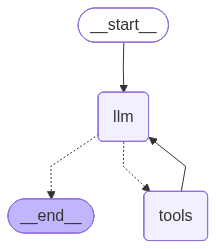

In [27]:
from typing import Any, Dict
from pydantic import BaseModel, field_validator, ValidationError

from langchain_core.tools import tool


from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, MessagesState, START, END

# --------------------------
# Domain schema (Pydantic)
# --------------------------
class WireTransferInput(BaseModel):
    """Inputs for executing a wire transfer."""
    destination_country: str
    amount: float

    @field_validator("destination_country")
    @classmethod
    def check_sanctions(cls, v: str) -> str:
        restricted = ["Mordor", "Narnia", "Atlantis"]
        if v.title() in restricted:
            raise ValueError(f"{v} is restricted for wire transfers.")
        return v

    @field_validator("amount")
    @classmethod
    def amount_positive(cls, v: float) -> float:
        if v <= 0:
            raise ValueError("Amount must be positive.")
        return v

# --------------------------
# Domain tool (Wire Transfer)
# --------------------------
@tool(args_schema=WireTransferInput)
def execute_wire_transfer(destination_country: str, amount: float) -> Dict[str, Any]:
    """
    Simulate a wire transfer.
    Raises ValueError for any domain-specific policy violations.
    """
    # Example policy: max transfer limit
    max_limit = 10000
    if amount > max_limit:
        raise ValueError(f"Transfer amount ${amount} exceeds max allowed ${max_limit}.")
    # Successful execution
    return {
        "status": "success",
        "message": f"✅ Transfer of ${amount} to {destination_country} completed."
    }

# --------------------------
# Custom ToolNode error handler
# --------------------------

def wire_error_handler(e: Exception) -> str:
    """Convert tool exceptions into a domain-friendly message."""
    # LangChain tool wraps validation errors in ToolException sometimes
    from langchain_core.tools import ToolException

    # If wrapped in ToolException, get the original error
    if isinstance(e, ToolException) and hasattr(e, "__cause__") and e.__cause__:
        e = e.__cause__

    # Pydantic validation errors
    if isinstance(e, ValidationError):
        issues = [f"- {'.'.join(map(str, err['loc']))}: {err['msg']}" for err in e.errors()]
        return "Wire transfer input validation failed:\n" + "\n".join(issues)

    # Domain errors raised inside tool
    if isinstance(e, ValueError):
        return f"Wire transfer error: {e}"

    # Fallback
    return f"Unknown error during wire transfer: {str(e)}"



# --------------------------
# Build LangGraph with ChatOllama + ToolNode
# --------------------------
tools = [execute_wire_transfer]
tool_node = ToolNode(tools, handle_tool_errors=wire_error_handler)


def call_llm(state: MessagesState):
    """LLM node: takes messages and returns an AIMessage."""
    llm_with_tools=llm.bind_tools(tools)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node("tools", tool_node)

# Flow edges
builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)  # Routes to tools or END
builder.add_edge("tools", "llm")  # Tool results go back to LLM

graph = builder.compile()

graph

In [28]:
from rich import print
# --------------------------
# Demo run
# --------------------------
# Good input
good_input = {
    "messages": [
        ("system", "You are a bank assistant. Execute wire transfers using the tool."),
        ("user", "Send $5000 to India.")
    ]
}

good_run = graph.invoke(good_input)
print("\n--- GOOD RUN ---")
for m in good_run["messages"]:
    print(m)


--- GOOD RUN ---

SystemMessage(
    content='You are a bank assistant. Execute wire transfers using the tool.',
    additional_kwargs={},
    response_metadata={},
    id='1f776c62-6922-4316-9300-e18f231d420e'
)

HumanMessage(
    content='Send $5000 to India.',
    additional_kwargs={},
    response_metadata={},
    id='c575a7c1-f2e1-4fdd-9517-476f7d2c2776'
)

AIMessage(
    content=[
        {'type': 'text', 'text': "I will use the execute_wire_transfer tool to carry out the user's request."},
        {
            'type': 'tool_use',
            'name': 'execute_wire_transfer',
            'input': {'amount': 5000, 'destination_country': 'India'},
            'id': 'tooluse_eMRbtpNg8uV9evWhY7VSp7'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': '9bd0b2e3-9ede-4d3e-89e3-3ce042b59217',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:49:31 GMT',
                'content-type': 'application/json',
                'content-length': '421',
                'connection': 'keep-alive',
                'x-amzn-requestid': '9bd0b2e3-9ede-4d3e-89e3-3ce042b59217'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [2303]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc0c-795d-73f2-97d5-2c10f18efa29-0',
    tool_calls=[
        {
            'name': 'execute_wire_transfer',
            'args': {'amount': 5000, 'destination_country': 'India'},
            'id': 'tooluse_eMRbtpNg8uV9evWhY7VSp7',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 46,
        'output_tokens': 37,
        'total_tokens': 83,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

ToolMessage(
    content='{"status": "success", "message": "✅ Transfer of $5000.0 to India completed."}',
    name='execute_wire_transfer',
    id='eaee6654-caa0-4353-883b-6295200dd88a',
    tool_call_id='tooluse_eMRbtpNg8uV9evWhY7VSp7'
)

AIMessage(
    content='The transfer of $5000 to India has been completed.',
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'cbfc2ebe-83cb-4956-8417-db811cb7e672',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:49:33 GMT',
                'content-type': 'application/json',
                'content-length': '255',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'cbfc2ebe-83cb-4956-8417-db811cb7e672'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [1849]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc0c-8341-7400-aa82-e4b56cd479d1-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 101,
        'output_tokens': 14,
        'total_tokens': 115,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

In [29]:
# Bad input (validation + policy failure)
bad_input = {
    "messages": [
        ("system", "You are a bank assistant. Execute wire transfers using the tool."),
        ("user", "Send $15000 to Mordor.")
    ]
}

bad_run = graph.invoke(bad_input)
print("\n--- BAD RUN (shows ToolNode custom error handling) ---")
for m in bad_run["messages"]:
    print(m)

--- BAD RUN (shows ToolNode custom error handling) ---

SystemMessage(
    content='You are a bank assistant. Execute wire transfers using the tool.',
    additional_kwargs={},
    response_metadata={},
    id='03caa648-9d45-4cad-b03f-0a1cdd4707a9'
)

HumanMessage(
    content='Send $15000 to Mordor.',
    additional_kwargs={},
    response_metadata={},
    id='a9316849-5b40-4a99-a784-7b753acfa06c'
)

AIMessage(
    content=[
        {'type': 'text', 'text': "I will use the execute_wire_transfer tool to complete the user's request."},
        {
            'type': 'tool_use',
            'name': 'execute_wire_transfer',
            'input': {'amount': 15000, 'destination_country': 'Mordor'},
            'id': 'tooluse_jbsOes3vONTuT8R8ragK44'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': '449438f9-0673-422d-bb3d-297ff46a1a8f',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:49:36 GMT',
                'content-type': 'application/json',
                'content-length': '422',
                'connection': 'keep-alive',
                'x-amzn-requestid': '449438f9-0673-422d-bb3d-297ff46a1a8f'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [2216]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc0c-8b76-7912-9110-7a41de00cbbd-0',
    tool_calls=[
        {
            'name': 'execute_wire_transfer',
            'args': {'amount': 15000, 'destination_country': 'Mordor'},
            'id': 'tooluse_jbsOes3vONTuT8R8ragK44',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 48,
        'output_tokens': 38,
        'total_tokens': 86,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

ToolMessage(
    content='Wire transfer input validation failed:\n- destination_country: Value error, Mordor is restricted for 
wire transfers.',
    name='execute_wire_transfer',
    id='bf98c9fc-b8bd-419b-b306-a2641664993a',
    tool_call_id='tooluse_jbsOes3vONTuT8R8ragK44',
    status='error'
)

AIMessage(
    content="I'm sorry, I cannot send money to Mordor as it is restricted for wire transfers.",
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': 'b6fdcde5-0608-4c0d-9c14-14450b5bb2e0',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:49:38 GMT',
                'content-type': 'application/json',
                'content-length': '285',
                'connection': 'keep-alive',
                'x-amzn-requestid': 'b6fdcde5-0608-4c0d-9c14-14450b5bb2e0'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [2443]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc0c-9502-7152-80a7-1555d4125b7c-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 100,
        'output_tokens': 19,
        'total_tokens': 119,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

In [31]:
# Bad input (validation + policy failure)
bad_input = {
    "messages": [
        ("system", "You are a bank assistant. Execute wire transfers using the tool."),
        ("user", "Send -500 to India.")
    ]
}

bad_run = graph.invoke(bad_input)
print("\n--- BAD RUN (shows ToolNode custom error handling) ---")
for m in bad_run["messages"]:
    print(m)

--- BAD RUN (shows ToolNode custom error handling) ---

SystemMessage(
    content='You are a bank assistant. Execute wire transfers using the tool.',
    additional_kwargs={},
    response_metadata={},
    id='8f4108cc-a3d1-4504-917c-b43c9012ac6e'
)

HumanMessage(
    content='Send -500 to India.',
    additional_kwargs={},
    response_metadata={},
    id='c83d81f6-e1b0-428b-8a4d-c9b7e1cabf79'
)

AIMessage(
    content=[
        {'type': 'text', 'text': 'I will use the execute_wire_transfer tool to answer this request.'},
        {
            'type': 'tool_use',
            'name': 'execute_wire_transfer',
            'input': {'amount': -500, 'destination_country': 'India'},
            'id': 'tooluse_THBhrMpcaaf0QC2ePmtsr8'
        }
    ],
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': '5e60130e-83f4-4c86-8fd9-abe5f16e87b0',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:53:49 GMT',
                'content-type': 'application/json',
                'content-length': '412',
                'connection': 'keep-alive',
                'x-amzn-requestid': '5e60130e-83f4-4c86-8fd9-abe5f16e87b0'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'tool_use',
        'metrics': {'latencyMs': [2089]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc10-6b14-7ce2-9d57-5ba5f99b3bbd-0',
    tool_calls=[
        {
            'name': 'execute_wire_transfer',
            'args': {'amount': -500, 'destination_country': 'India'},
            'id': 'tooluse_THBhrMpcaaf0QC2ePmtsr8',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 45,
        'output_tokens': 33,
        'total_tokens': 78,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

ToolMessage(
    content='Wire transfer input validation failed:\n- amount: Value error, Amount must be positive.',
    name='execute_wire_transfer',
    id='5a915474-a9b4-44a9-860c-998dbf05995f',
    tool_call_id='tooluse_THBhrMpcaaf0QC2ePmtsr8',
    status='error'
)

AIMessage(
    content="I'm sorry, I cannot execute a wire transfer with a negative amount. Please try again with a positive 
amount.",
    additional_kwargs={},
    response_metadata={
        'ResponseMetadata': {
            'RequestId': '5cb47f81-62d4-4b03-912a-9001f62d6798',
            'HTTPStatusCode': 200,
            'HTTPHeaders': {
                'date': 'Wed, 06 May 2026 06:53:52 GMT',
                'content-type': 'application/json',
                'content-length': '312',
                'connection': 'keep-alive',
                'x-amzn-requestid': '5cb47f81-62d4-4b03-912a-9001f62d6798'
            },
            'RetryAttempts': 0
        },
        'stopReason': 'end_turn',
        'metrics': {'latencyMs': [2303]},
        'model_provider': 'bedrock_converse',
        'model_name': 'cohere.command-r-plus-v1:0'
    },
    id='lc_run--019dfc10-7421-76a1-8ec3-c96e56b0871d-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 90,
        'output_tokens': 23,
        'total_tokens': 113,
        'input_token_details': {'cache_creation': 0, 'cache_read': 0}
    }
)

## Tool Node With Validation V2

In [ ]:
## Validation Schema itself is used as a tool

In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition, ValidationNode
from pydantic import BaseModel, Field, field_validator
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langchain.tools import tool
from langchain_core.messages import ToolMessage, HumanMessage

In [2]:
import os


# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0",cohere.command-r-plus-v1:0 region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id= "anthropic.claude-3-sonnet-20240229-v1:0",          #"amazon.nova-lite-v1:0", 
                          region_name="us-east-1",
                          temperature=0.5, 
                          max_tokens=1000)

llm.invoke('hi').content

'Hello!'

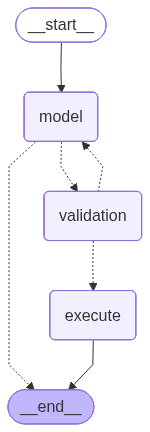

In [8]:
from typing import Literal, Annotated, TypedDict
from langchain_core.messages import BaseMessage, ToolMessage, AIMessage
from pydantic import BaseModel, field_validator
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

# Use a TypedDict for the State
class State(TypedDict):
    # add_messages ensures new messages are appended to the list
    messages: Annotated[list[BaseMessage], add_messages]

class WireTransfer(BaseModel):
    destination_country: str
    amount: float

    @field_validator("destination_country")
    def check_sanctions(cls, v):
        restricted = ["Mordor", "Narnia", "Atlantis"]
        if v.title() in restricted:
            raise ValueError(f"{v} is restricted. Please provide a sanctioned-free country.")
        return v

# Call LLM
def call_model(state: State):
    llm_with_tool = llm.bind_tools([WireTransfer])
    response = llm_with_tool.invoke(state["messages"])
    # MUST return a dict
    return {"messages": [response]}

def validation_node(state: State):
    last_msg = state["messages"][-1]
    # Extract the tool call
    tool_call = last_msg.tool_calls[0]
    
    try:
        # Validate using Pydantic
        WireTransfer(**tool_call["args"])
        # Return a ToolMessage with success metadata
        return {
            "messages": [ToolMessage(
                content="Validation succeeded", 
                tool_call_id=tool_call["id"],
                additional_kwargs={"is_error": False}
            )]
        }
    except Exception as e:
        # Return the error message to the LLM so it can retry
        return {
            "messages": [ToolMessage(
                content=str(e), 
                tool_call_id=tool_call["id"],
                additional_kwargs={"is_error": True}
            )]
        }

def execute_transfer(state: State):
    # Find the original AIMessage to get the transfer details
    for msg in reversed(state["messages"]):
        if isinstance(msg, AIMessage) and msg.tool_calls:
            data = msg.tool_calls[0]["args"]
            break

    confirmation = f" Transfer Processed: ${data['amount']} sent to {data['destination_country']}."
    return {"messages": [AIMessage(content=confirmation)]}

#  Graph Construction
builder = StateGraph(State)
builder.add_node("model", call_model)
builder.add_node("validation", validation_node)
builder.add_node("execute", execute_transfer)

builder.add_edge(START, "model")

def should_validate(state: State) -> Literal["validation", "__end__"]:
    if state["messages"][-1].tool_calls:
        return "validation"
    return END

def check_validation_result(state: State) -> Literal["model", "execute"]:
    # Check the metadata we set in the validation node
    if state["messages"][-1].additional_kwargs.get("is_error"):
        return "model"
    return "execute"

builder.add_conditional_edges("model", should_validate)
builder.add_conditional_edges("validation", check_validation_result)
builder.add_edge("execute", END)

graph = builder.compile()

graph

In [9]:
# Running the flow
inputs = {"messages": [("user", "I want to send $500 to India.")]}
res = graph.invoke(inputs)
for msg in res["messages"]:
    msg.pretty_print()


================================ Human Message =================================

I want to send $500 to India.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Okay, to send $500 to India, we can use the WireTransfer tool:'}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'India'}, 'id': 'tooluse_nRRAPROzVADW5fONE8PHHI'}]
Tool Calls:
  WireTransfer (tooluse_nRRAPROzVADW5fONE8PHHI)
 Call ID: tooluse_nRRAPROzVADW5fONE8PHHI
  Args:
    amount: 500
    destination_country: India
================================= Tool Message =================================

Validation succeeded
================================== Ai Message ==================================

✅ Transfer Processed: $500 sent to India.


In [10]:
# Run 2
inputs = {"messages": [("user", "I want to send $500 to Mordor.")]}
res = graph.invoke(inputs)
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

I want to send $500 to Mordor.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Okay, to send $500 to Mordor, we can use the WireTransfer tool:'}, {'type': 'tool_use', 'name': 'WireTransfer', 'input': {'amount': 500, 'destination_country': 'Mordor'}, 'id': 'tooluse_wgIsTebKvZdY7CpSUPtzaU'}]
Tool Calls:
  WireTransfer (tooluse_wgIsTebKvZdY7CpSUPtzaU)
 Call ID: tooluse_wgIsTebKvZdY7CpSUPtzaU
  Args:
    amount: 500
    destination_country: Mordor
================================= Tool Message =================================

1 validation error for WireTransfer
destination_country
  Value error, Mordor is restricted. Please provide a sanctioned-free country. [type=value_error, input_value='Mordor', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error
================================== Ai Message ========